# Modelo Proyecto 2 

#### Importo las librerías necesarias 

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import mlflow.tensorflow
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score


#### Importo los datos 

In [3]:
df = pd.read_csv("Clean_data.csv")

print(df.head)
print(df.shape)

<bound method NDFrame.head of       periodo estu_tipodocumento  estu_consecutivo cole_area_ubicacion  \
0       20181                 CC  SB11201810003214              URBANO   
1       20181                 CC  SB11201810003214              URBANO   
2       20181                 TI  SB11201810043861               RURAL   
3       20181                 TI  SB11201810043861               RURAL   
4       20181                 CC  SB11201810004937               RURAL   
...       ...                ...               ...                 ...   
32338   20181                 TI  SB11201810001140              URBANO   
32339   20181                 TI  SB11201810024724              URBANO   
32340   20181                 TI  SB11201810024724              URBANO   
32341   20181                 TI  SB11201810019065              URBANO   
32342   20181                 TI  SB11201810019065              URBANO   

      cole_bilingue cole_calendario cole_caracter  \
0                No         

#### Identifico los NAs en los datos  y revisamos el tipo de datos

In [4]:
df.isna().sum()
df.dropna(inplace=True)
df.dtypes

periodo                           object
estu_tipodocumento                object
estu_consecutivo                  object
cole_area_ubicacion               object
cole_bilingue                     object
cole_calendario                   object
cole_caracter                     object
cole_cod_dane_establecimiento    float64
cole_cod_dane_sede               float64
cole_cod_depto_ubicacion         float64
cole_cod_mcpio_ubicacion         float64
cole_codigo_icfes                float64
cole_depto_ubicacion              object
cole_genero                       object
cole_jornada                      object
cole_mcpio_ubicacion              object
cole_naturaleza                   object
cole_nombre_establecimiento       object
cole_nombre_sede                  object
cole_sede_principal               object
estu_cod_depto_presentacion      float64
estu_cod_mcpio_presentacion      float64
estu_cod_reside_depto            float64
estu_cod_reside_mcpio            float64
estu_depto_prese

### Definimos listas para las variables categóricas enteras, categóricas string y numéricas.

In [5]:
#Seleccionar solo las variables socio demograficas y de entorno educativo 

variables_sociodemograficas = [
    'cole_area_ubicacion', 'cole_bilingue', 'cole_calendario', 'cole_caracter',
    'cole_genero', 'cole_jornada', 'cole_naturaleza', 'cole_depto_ubicacion', 'cole_mcpio_ubicacion',
    'estu_tipodocumento', 'estu_genero', 'estu_depto_reside', 'estu_mcpio_reside',
    'estu_nacionalidad', 'estu_pais_reside', 'estu_privado_libertad',
    'fami_cuartoshogar', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_estratovivienda',
    'fami_personashogar', 'fami_tieneautomovil', 'fami_tienecomputador', 'fami_tieneinternet', 'fami_tienelavadora'
]

### Calculo el promedio nacional del promedio global

In [6]:
promedio_nacional = df['punt_global'].mean()
print(f"Promedio nacional de puntaje global: {promedio_nacional:.2f}")

Promedio nacional de puntaje global: 300.43


#### Creo columna de desempeño (0 =Bajo, 1 = Medio, 2 = Alto)

In [7]:
def clasificar_desempeno(puntaje):
    if puntaje < promedio_nacional * 0.9:
        return 0  # bajo
    elif puntaje < promedio_nacional * 1.1:
        return 1  # medio
    else:
        return 2  # alto

df['desempeno'] = df['punt_global'].apply(clasificar_desempeno)

### Convertir la variables categoricas a dummies 

### Uno las númericas con las dummies 

In [8]:
X = pd.get_dummies(df[variables_sociodemograficas])
y = df['desempeno']

### Entreno el modelo

In [9]:
# Tomamos el 80% para entrenamiento
train = X.sample(frac=0.8, random_state=100)
# El resto será test
test = X.drop(train.index)

# De train, sacamos el 20% para validación
val = train.sample(frac=0.2, random_state=100)
# Actualizamos train quitando las filas que se fueron a validación
train = train.drop(val.index)

# Separar etiquetas
y_train = y[train.index]
y_val = y[val.index]
y_test = y[test.index]

# Confirmar tamaños
print("Train:", train.shape, "Validation:", val.shape, "Test:", test.shape)

# Guardar las columnas usadas para entrenar el modelo
np.save("columnas_modelo.npy", train.columns.to_numpy())

Train: (20542, 584) Validation: (5135, 584) Test: (6419, 584)


### Modelo 

In [10]:
# Configurar experimento en MLflow
mlflow.set_experiment('Experimento con capas')
mlflow.tensorflow.autolog()

## Modelo1: con dos capas ocultas y 32 neuronas en cada capa, 3 de salida  

2025/05/25 21:05:58 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2025/05/25 21:05:58 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Epoch 1/20
639/642 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5987 - loss: 0.8489

642/642 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.5989 - loss: 0.8486 - val_accuracy: 0.6436 - val_loss: 0.7725
Epoch 2/20
632/642 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6421 - loss: 0.7661

642/642 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6422 - loss: 0.7660 - val_accuracy: 0.6407 - val_loss: 0.7661
Epoch 3/20
639/642 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6503 - loss: 0.7449

642/642 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6503 - loss: 0.7449 - val_accuracy: 0.6452 - val_loss: 0.7576
Epoch 4/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6660 - loss: 0.7290

642/642 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6660 - loss: 0.7290 - val_accuracy: 0.6450 - val_loss: 0.7576
Epoch 5/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6679 - loss: 0.7164 - val_accuracy: 0.6508 - val_loss: 0.7583
Epoch 6/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6683 - loss: 0.7178 - val_accuracy: 0.6504 - val_loss: 0.7587
Epoch 7/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6725 - loss: 0.7139 - val_accuracy: 0.6417 - val_loss: 0.7625
Epoch 8/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6840 - loss: 0.6916 - val_accuracy: 0.6499 - val_loss: 0.7621
Epoch 9/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6866 - loss: 0.6876 - val_accuracy: 0.6495 - val_loss: 0.7611
Epoch 10/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6908 - loss: 0.6743 - val_accuracy: 0.6504 - val_loss: 0.7613
Epoch 11/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6946 - loss: 0.6671 - val_accuracy: 0.64

2025/05/25 21:08:21 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/25 21:08:21 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/25 21:09:02 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6708 - loss: 0.7648
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Modelo 1 - Accuracy: 0.6655, Loss: 0.7687, MSE: 0.4279, R²: 0.3587


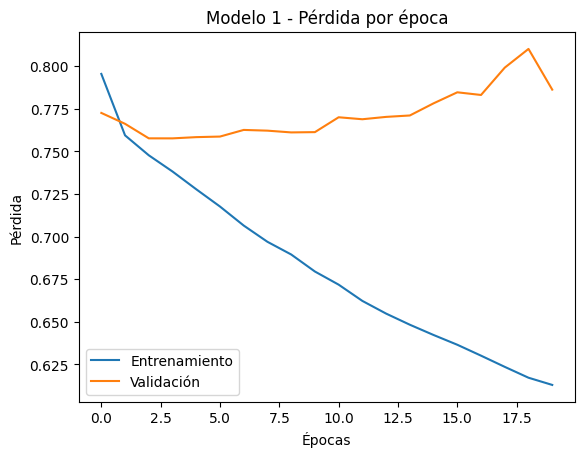

In [11]:
with mlflow.start_run(run_name='Modelo 1'):
    model1 = keras.Sequential([
        keras.Input(shape=(train.shape[1],)),  # Capa de entrada
        layers.Dense(32, activation='relu'),   # Primera capa oculta
        layers.Dense(32, activation='relu'),   # Segunda capa oculta
        layers.Dense(3, activation='softmax')  # Capa de salida (3 clases)
    ])

    model1.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history1 = model1.fit(
        train, y_train,
        validation_data=(val, y_val),
        epochs=20,
        batch_size=32
    )

    # Evaluar en test
    test_loss1, test_acc1 = model1.evaluate(test, y_test)
    mlflow.log_metric('test_accuracy', test_acc1)
    mlflow.log_metric('test_loss', test_loss1)

    # Obtener predicciones (probabilidades)
    predicciones_prob = model1.predict(test)
    # Convertir a clases 0,1,2
    predicciones = np.argmax(predicciones_prob, axis=1)

    # Calcular MSE y R²
    mse = mean_squared_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)

    # Log de métricas adicionales en MLflow
    mlflow.log_metric("MSE", mse)
    mlflow.log_metric("R2", r2)

    print(f"Modelo 1 - Accuracy: {test_acc1:.4f}, Loss: {test_loss1:.4f}, MSE: {mse:.4f}, R²: {r2:.4f}")

    # Gráfica de pérdidas
    plt.plot(history1.history['loss'], label='Entrenamiento')
    plt.plot(history1.history['val_loss'], label='Validación')
    plt.title('Modelo 1 - Pérdida por época')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()


## Modelo 2: con tres capas 16 neuronas en cada capa, capa de normalización y tres salidas 

2025/05/25 21:09:24 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2025/05/25 21:09:24 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Epoch 1/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5881 - loss: 0.8575

642/642 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.5881 - loss: 0.8574 - val_accuracy: 0.6430 - val_loss: 0.7677
Epoch 2/20
638/642 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6489 - loss: 0.7635

642/642 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6489 - loss: 0.7635 - val_accuracy: 0.6405 - val_loss: 0.7667
Epoch 3/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6513 - loss: 0.7491 - val_accuracy: 0.6382 - val_loss: 0.7704
Epoch 4/20
638/642 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6503 - loss: 0.7543

642/642 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6503 - loss: 0.7542 - val_accuracy: 0.6389 - val_loss: 0.7645
Epoch 5/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6637 - loss: 0.7323 - val_accuracy: 0.6397 - val_loss: 0.7673
Epoch 6/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6626 - loss: 0.7346 - val_accuracy: 0.6423 - val_loss: 0.7656
Epoch 7/20
638/642 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6636 - loss: 0.7291

642/642 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6635 - loss: 0.7291 - val_accuracy: 0.6442 - val_loss: 0.7611
Epoch 8/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6674 - loss: 0.7241 - val_accuracy: 0.6462 - val_loss: 0.7679
Epoch 9/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6634 - loss: 0.7273 - val_accuracy: 0.6456 - val_loss: 0.7693
Epoch 10/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6791 - loss: 0.7089 - val_accuracy: 0.6399 - val_loss: 0.7629
Epoch 11/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6716 - loss: 0.7122 - val_accuracy: 0.6374 - val_loss: 0.7672
Epoch 12/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6762 - loss: 0.7083 - val_accuracy: 0.6407 - val_loss: 0.7617
Epoch 13/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6781 - loss: 0.6996 - val_accuracy: 0.6391 - val_loss: 0.7640
Epoch 14/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6810 - loss: 0.6945 - val_accuracy: 0.6438

2025/05/25 21:11:09 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/25 21:11:09 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/25 21:11:43 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6480 - loss: 0.7671
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Modelo 2 - Accuracy: 0.6478, Loss: 0.7632, MSE: 0.4083, R²: 0.3881


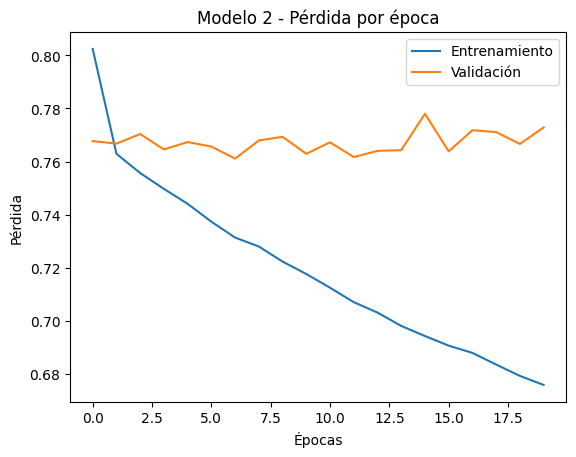

In [12]:
with mlflow.start_run(run_name='Modelo2'):
    model2 = keras.Sequential([
        keras.Input(shape=(train.shape[1],)),
        layers.Normalization(),
        layers.Dense(16, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])

    model2.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history2 = model2.fit(
        train, y_train,
        validation_data=(val, y_val),
        epochs=20,
        batch_size=32
    )

    # Evaluar en test
    test_loss2, test_acc2 = model2.evaluate(test, y_test)
    mlflow.log_metric('test_accuracy', test_acc2)
    mlflow.log_metric('test_loss', test_loss2)

    # Obtener predicciones del Modelo 2
    predicciones_prob = model2.predict(test)
    predicciones = np.argmax(predicciones_prob, axis=1)

    # Calcular MSE y R² del Modelo 2
    mse = mean_squared_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)

    mlflow.log_metric("MSE", mse)
    mlflow.log_metric("R2", r2)

    print(f"Modelo 2 - Accuracy: {test_acc2:.4f}, Loss: {test_loss2:.4f}, MSE: {mse:.4f}, R²: {r2:.4f}")

    # Gráfica de pérdidas
    plt.plot(history2.history['loss'], label='Entrenamiento')
    plt.plot(history2.history['val_loss'], label='Validación')
    plt.title('Modelo 2 - Pérdida por época')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()


### Modelo 3: con 4 capas ocultas y 64 neurnonas en dos capas y 32 neuronas en dos, 3 de salida 

2025/05/25 21:12:17 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2025/05/25 21:12:17 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Epoch 1/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5921 - loss: 0.8536

642/642 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.5922 - loss: 0.8535 - val_accuracy: 0.6417 - val_loss: 0.7649
Epoch 2/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.6443 - loss: 0.7611 - val_accuracy: 0.6321 - val_loss: 0.7813
Epoch 3/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6535 - loss: 0.7445

642/642 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6535 - loss: 0.7445 - val_accuracy: 0.6477 - val_loss: 0.7602
Epoch 4/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6616 - loss: 0.7322 - val_accuracy: 0.6456 - val_loss: 0.7678
Epoch 5/20
636/642 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6731 - loss: 0.7139

642/642 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6730 - loss: 0.7140 - val_accuracy: 0.6456 - val_loss: 0.7579
Epoch 6/20
641/642 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6845 - loss: 0.6933

642/642 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.6845 - loss: 0.6933 - val_accuracy: 0.6547 - val_loss: 0.7532
Epoch 7/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6954 - loss: 0.6709 - val_accuracy: 0.6473 - val_loss: 0.7742
Epoch 8/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7030 - loss: 0.6565 - val_accuracy: 0.6522 - val_loss: 0.7673
Epoch 9/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7123 - loss: 0.6354 - val_accuracy: 0.6557 - val_loss: 0.7712
Epoch 10/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7300 - loss: 0.6144 - val_accuracy: 0.6656 - val_loss: 0.7852
Epoch 11/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7373 - loss: 0.5911 - val_accuracy: 0.6576 - val_loss: 0.7983
Epoch 12/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7478 - loss: 0.5709 - val_accuracy: 0.6660 - val_loss: 0.7893
Epoch 13/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7593 - loss: 0.5480 - val_accuracy: 0.64

2025/05/25 21:14:31 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/25 21:14:31 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/25 21:15:08 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6913 - loss: 0.8764
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Modelo 3 - Accuracy: 0.6923, Loss: 0.8699, MSE: 0.3932, R²: 0.4107


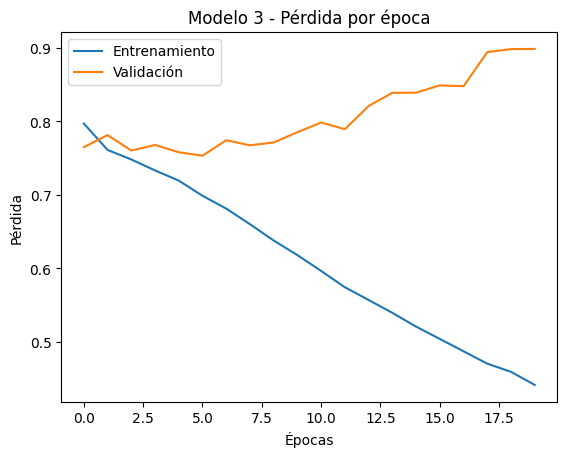

In [13]:
with mlflow.start_run(run_name='Modelo3'):
    model3 = keras.Sequential([
        keras.Input(shape=(train.shape[1],)),  # Capa de entrada
        layers.Dense(64, activation='relu'),  # Primera capa oculta
        layers.Dense(64, activation='relu'),   # Segunda capa oculta
        layers.Dense(32, activation='relu'),   # Tercera capa oculta
        layers.Dense(32, activation='relu'),   # Cuarta capa oculta
        layers.Dense(3, activation='softmax')  # Capa de salida
    ])

    model3.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history3 = model3.fit(
        train, y_train,
        validation_data=(val, y_val),
        epochs=20,
        batch_size=32
    )

    test_loss3, test_acc3 = model3.evaluate(test, y_test)
    mlflow.log_metric('test_accuracy', test_acc3)
    mlflow.log_metric('test_loss', test_loss3)

     # Obtener predicciones del Modelo 3
    predicciones_prob = model3.predict(test)
    predicciones = np.argmax(predicciones_prob, axis=1)
    
    # Calcular MSE y R²
    mse = mean_squared_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)

    # Log de métricas adicionales en MLflow
    mlflow.log_metric("MSE", mse)
    mlflow.log_metric("R2", r2)

    print(f"Modelo 3 - Accuracy: {test_acc3:.4f}, Loss: {test_loss3:.4f}, MSE: {mse:.4f}, R²: {r2:.4f}")

    plt.plot(history3.history['loss'], label='Entrenamiento')
    plt.plot(history3.history['val_loss'], label='Validación')
    plt.title('Modelo 3 - Pérdida por época')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()


### Modelo 4: con 4 capas ocultas 32 neuronas en cada capa, 1 capa de normalización y tres  de salidad

2025/05/25 21:19:18 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2025/05/25 21:19:18 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Epoch 1/20
641/642 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5877 - loss: 0.8468

642/642 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.5878 - loss: 0.8467 - val_accuracy: 0.6454 - val_loss: 0.7677
Epoch 2/20
640/642 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6443 - loss: 0.7613

642/642 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.6443 - loss: 0.7613 - val_accuracy: 0.6432 - val_loss: 0.7667
Epoch 3/20
634/642 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6544 - loss: 0.7472

642/642 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6544 - loss: 0.7473 - val_accuracy: 0.6415 - val_loss: 0.7631
Epoch 4/20
638/642 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6615 - loss: 0.7368

...

642/642 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.6616 - loss: 0.7321 - val_accuracy: 0.6491 - val_loss: 0.7588
Epoch 6/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6615 - loss: 0.7253 - val_accuracy: 0.6351 - val_loss: 0.7782
Epoch 7/20
640/642 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6708 - loss: 0.7154

642/642 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6708 - loss: 0.7154 - val_accuracy: 0.6477 - val_loss: 0.7584
Epoch 8/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6802 - loss: 0.7027

642/642 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6802 - loss: 0.7027 - val_accuracy: 0.6493 - val_loss: 0.7565
Epoch 9/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6847 - loss: 0.7012 - val_accuracy: 0.6497 - val_loss: 0.7578
Epoch 10/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6936 - loss: 0.6813 - val_accuracy: 0.6500 - val_loss: 0.7587
Epoch 11/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.6953 - loss: 0.6788 - val_accuracy: 0.6467 - val_loss: 0.7602
Epoch 12/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6956 - loss: 0.6721 - val_accuracy: 0.6537 - val_loss: 0.7659
Epoch 13/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7093 - loss: 0.6582 - val_accuracy: 0.6460 - val_loss: 0.7789
Epoch 14/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7076 - loss: 0.6607 - val_accuracy: 0.6516 - val_loss: 0.7701
Epoch 15/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7204 - loss: 0.6324 - val_accuracy: 0

2025/05/25 21:21:28 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/25 21:21:28 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/25 21:21:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6709 - loss: 0.7802
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Modelo 4 - Accuracy: 0.6655, Loss: 0.7687, MSE: 0.3887, R²: 0.4175


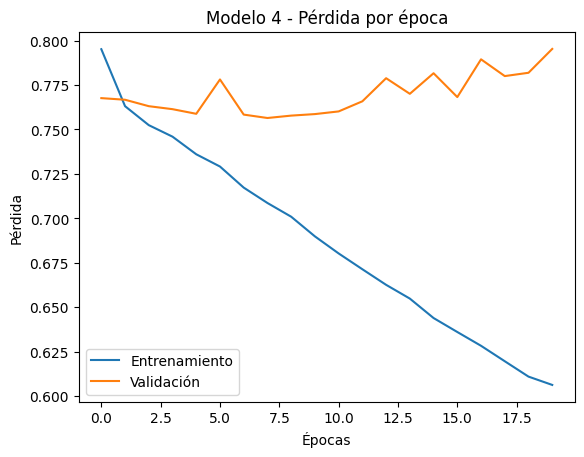

In [14]:
with mlflow.start_run(run_name='Modelo4'):
    model4 = keras.Sequential([
        keras.Input(shape=(train.shape[1],)),  # Capa de entrada
        layers.Normalization(),               # Normalización
        layers.Dense(32, activation='relu'),  # Primera capa oculta
        layers.Dense(32, activation='relu'),  # Segunda capa oculta
        layers.Dense(32, activation='relu'),   # Tercera capa oculta
        layers.Dense(32, activation='relu'),   # Cuarta capa oculta
        layers.Dense(3, activation='softmax')  # Capa de salida
    ])

    model4.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history4 = model4.fit(
        train, y_train,
        validation_data=(val, y_val),
        epochs=20,
        batch_size=32
    )

    test_loss4, test_acc4 = model4.evaluate(test, y_test)
    mlflow.log_metric('test_accuracy', test_acc4)
    mlflow.log_metric('test_loss', test_loss4)

    # Obtener predicciones del Modelo 4
    predicciones_prob = model4.predict(test)
    predicciones = np.argmax(predicciones_prob, axis=1)

    # Calcular MSE y R² del Modelo 4
    mse = mean_squared_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)

    print(f"Modelo 4 - Accuracy: {test_acc1:.4f}, Loss: {test_loss1:.4f}, MSE: {mse:.4f}, R²: {r2:.4f}")

    plt.plot(history4.history['loss'], label='Entrenamiento')
    plt.plot(history4.history['val_loss'], label='Validación')
    plt.title('Modelo 4 - Pérdida por época')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()


### Modelo 5: 5 capas ocultas con variando el número de neuronas de 32 a 256 en cada capa y 3 salidas 

2025/05/25 21:31:08 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2025/05/25 21:31:08 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Epoch 1/20
640/642 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6021 - loss: 0.8266

642/642 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.6023 - loss: 0.8264 - val_accuracy: 0.6356 - val_loss: 0.7821
Epoch 2/20
640/642 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6468 - loss: 0.7563

642/642 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6469 - loss: 0.7563 - val_accuracy: 0.6448 - val_loss: 0.7640
Epoch 3/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6584 - loss: 0.7357 - val_accuracy: 0.6432 - val_loss: 0.7684
Epoch 4/20
639/642 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6635 - loss: 0.7248

642/642 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6635 - loss: 0.7248 - val_accuracy: 0.6499 - val_loss: 0.7542
Epoch 5/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6874 - loss: 0.6812

642/642 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6874 - loss: 0.6812 - val_accuracy: 0.6615 - val_loss: 0.7401
Epoch 6/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.7122 - loss: 0.6402 - val_accuracy: 0.6672 - val_loss: 0.7561
Epoch 7/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7244 - loss: 0.6015 - val_accuracy: 0.6641 - val_loss: 0.7717
Epoch 8/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7659 - loss: 0.5462 - val_accuracy: 0.6740 - val_loss: 0.7892
Epoch 9/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7730 - loss: 0.5161 - val_accuracy: 0.6740 - val_loss: 0.8247
Epoch 10/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7922 - loss: 0.4746 - val_accuracy: 0.6851 - val_loss: 0.8443
Epoch 11/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8110 - loss: 0.4362 - val_accuracy: 0.6915 - val_loss: 0.9237
Epoch 12/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8330 - loss: 0.3949 - val_accuracy: 0

2025/05/25 21:34:08 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/25 21:34:08 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/25 21:34:52 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7440 - loss: 1.2332
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Modelo 5 - Accuracy: 0.6655, Loss: 0.7687, MSE: 0.3334, R²: 0.5004


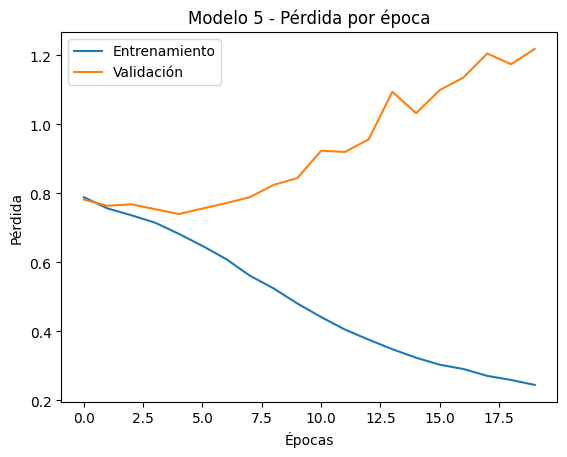

In [15]:
with mlflow.start_run(run_name='Modelo5_5'):
    model5 = keras.Sequential([
        keras.Input(shape=(train.shape[1],)),  # Capa de entrada
        layers.Dense(256, activation='relu'),  # Primera capa oculta
        layers.Dense(128, activation='relu'),  # Segunda capa oculta
        layers.Dense(96, activation='relu'),   # Tercera capa oculta
        layers.Dense(64, activation='relu'),   # Cuarta capa oculta
        layers.Dense(32, activation='relu'),   # Quinta capa oculta
        layers.Dense(3, activation='softmax')  # Capa de salida
    ])

    model5.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history5 = model5.fit(
        train, y_train,
        validation_data=(val, y_val),
        epochs=20,
        batch_size=32
    )

    test_loss5, test_acc5 = model5.evaluate(test, y_test)
    mlflow.log_metric('test_accuracy', test_acc5)
    mlflow.log_metric('test_loss', test_loss5)

    # Obtener predicciones del Modelo 5
    predicciones_prob = model5.predict(test)
    predicciones = np.argmax(predicciones_prob, axis=1)

    # Calcular MSE y R² del Modelo 5
    mse = mean_squared_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)

    print(f"Modelo 5 - Accuracy: {test_acc1:.4f}, Loss: {test_loss1:.4f}, MSE: {mse:.4f}, R²: {r2:.4f}")

    plt.plot(history5.history['loss'], label='Entrenamiento')
    plt.plot(history5.history['val_loss'], label='Validación')
    plt.title('Modelo 5 - Pérdida por época')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()


### Modelo 6: 5 Capas ocultas, 128 neurnonas en la primera capa, 64 en la segunda y tercera capa, 32 neuronas en las dos últimas capas y 3 salidas 

2025/05/25 21:45:17 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2025/05/25 21:45:17 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Epoch 1/20
638/642 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6062 - loss: 0.8346

642/642 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6063 - loss: 0.8343 - val_accuracy: 0.6411 - val_loss: 0.7684
Epoch 2/20
641/642 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6388 - loss: 0.7649

642/642 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6389 - loss: 0.7649 - val_accuracy: 0.6426 - val_loss: 0.7642
Epoch 3/20
639/642 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6549 - loss: 0.7488

642/642 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6549 - loss: 0.7488 - val_accuracy: 0.6458 - val_loss: 0.7591
Epoch 4/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6623 - loss: 0.7300

642/642 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6623 - loss: 0.7300 - val_accuracy: 0.6495 - val_loss: 0.7567
Epoch 5/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6668 - loss: 0.7117

642/642 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6668 - loss: 0.7117 - val_accuracy: 0.6493 - val_loss: 0.7559
Epoch 6/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6903 - loss: 0.6809 - val_accuracy: 0.6469 - val_loss: 0.7640
Epoch 7/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.6992 - loss: 0.6628 - val_accuracy: 0.6553 - val_loss: 0.7621
Epoch 8/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.7119 - loss: 0.6296 - val_accuracy: 0.6615 - val_loss: 0.7658
Epoch 9/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7327 - loss: 0.5969 - val_accuracy: 0.6619 - val_loss: 0.7662
Epoch 10/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.7453 - loss: 0.5707 - val_accuracy: 0.6689 - val_loss: 0.8001
Epoch 11/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7608 - loss: 0.5428 - val_accuracy: 0.6754 - val_loss: 0.8115
Epoch 12/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7771 - loss: 0.5141 - val_accuracy

2025/05/25 21:48:30 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/25 21:48:30 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/25 21:49:16 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7273 - loss: 0.9313
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Modelo 6 - Accuracy: 0.6655, Loss: 0.7687, MSE: 0.3603, R²: 0.4600


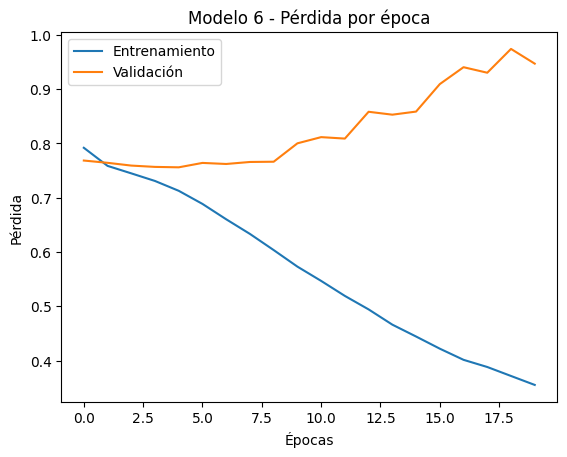

In [17]:
with mlflow.start_run(run_name='Modelo6'):
    model6 = keras.Sequential([
        keras.Input(shape=(train.shape[1],)),   # Capa de entrada
        layers.Dense(128, activation='relu'),   # Primera capa oculta (128)
        layers.Dense(64, activation='relu'),    # Segunda capa oculta (64)
        layers.Dense(64, activation='relu'),    # Tercera capa oculta (64)
        layers.Dense(32, activation='relu'),    # Cuarta capa oculta (32)
        layers.Dense(32, activation='relu'),    # Quinta capa oculta (32)
        layers.Dense(3, activation='softmax')   # Capa de salida (3 clases)
    ])

    model6.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history6 = model6.fit(
        train, y_train,
        validation_data=(val, y_val),
        epochs=20,
        batch_size=32
    )

    test_loss6, test_acc6 = model6.evaluate(test, y_test)
    mlflow.log_metric('test_accuracy', test_acc6)
    mlflow.log_metric('test_loss', test_loss6)

    # Obtener predicciones del Modelo 6
    predicciones_prob = model6.predict(test)
    predicciones = np.argmax(predicciones_prob, axis=1)

    # Calcular MSE y R² del Modelo 6
    mse = mean_squared_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)

    print(f"Modelo 6 - Accuracy: {test_acc1:.4f}, Loss: {test_loss1:.4f}, MSE: {mse:.4f}, R²: {r2:.4f}")

    plt.plot(history6.history['loss'], label='Entrenamiento')
    plt.plot(history6.history['val_loss'], label='Validación')
    plt.title('Modelo 6 - Pérdida por época')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()



### Modelo 7: 3 Capas y 256 neuronas en la primera capa, 128 neuronas en cada capa con 3 salidas 

2025/05/25 22:04:08 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2025/05/25 22:04:08 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Epoch 1/20
641/642 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6157 - loss: 0.8083

642/642 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.6158 - loss: 0.8082 - val_accuracy: 0.6399 - val_loss: 0.7753
Epoch 2/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6453 - loss: 0.7584 - val_accuracy: 0.6152 - val_loss: 0.7985
Epoch 3/20
638/642 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6531 - loss: 0.7429

642/642 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6531 - loss: 0.7428 - val_accuracy: 0.6465 - val_loss: 0.7641
Epoch 4/20
640/642 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6675 - loss: 0.7142

642/642 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6675 - loss: 0.7141 - val_accuracy: 0.6481 - val_loss: 0.7582
Epoch 5/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6928 - loss: 0.6702 - val_accuracy: 0.6571 - val_loss: 0.7700
Epoch 6/20
641/642 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7086 - loss: 0.6358

642/642 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7086 - loss: 0.6358 - val_accuracy: 0.6600 - val_loss: 0.7513
Epoch 7/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7411 - loss: 0.5873 - val_accuracy: 0.6635 - val_loss: 0.7812
Epoch 8/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7553 - loss: 0.5528 - val_accuracy: 0.6660 - val_loss: 0.8226
Epoch 9/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7838 - loss: 0.4936 - val_accuracy: 0.6869 - val_loss: 0.8266
Epoch 10/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8008 - loss: 0.4528 - val_accuracy: 0.6929 - val_loss: 0.8715
Epoch 11/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8224 - loss: 0.4138 - val_accuracy: 0.6927 - val_loss: 0.9176
Epoch 12/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8422 - loss: 0.3707 - val_accuracy: 0.6997 - val_loss: 1.0116
Epoch 13/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8502 - loss: 0.3529 - val_accuracy: 0.7

2025/05/25 22:07:18 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/25 22:07:18 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/25 22:08:23 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7437 - loss: 1.2384
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Modelo 7 - Accuracy: 0.7489, Loss: 1.2405, MSE: 0.4083, R²: 0.3881


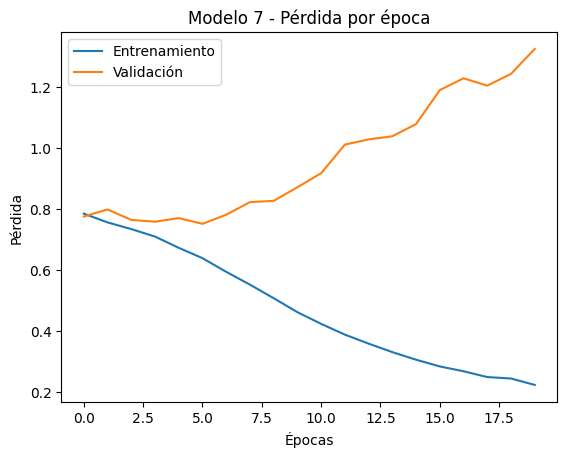

In [27]:
with mlflow.start_run(run_name='Modelo7'):
    model7 = keras.Sequential([
        keras.Input(shape=(train.shape[1],)),   # Capa de entrada
        layers.Dense(256, activation='relu'),   # Primera capa oculta (128)
        layers.Dense(128, activation='relu'),    # Segunda capa oculta (64)
        layers.Dense(128, activation='relu'),    # Tercera capa oculta (64)
        layers.Dense(3, activation='softmax')   # Capa de salida (3 clases)
    ])

    model7.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history7 = model7.fit(
        train, y_train,
        validation_data=(val, y_val),
        epochs=20,
        batch_size=32
    )

    test_loss7, test_acc7 = model7.evaluate(test, y_test)
    mlflow.log_metric('test_accuracy', test_acc7)
    mlflow.log_metric('test_loss', test_loss7)

    # Obtener predicciones del Modelo 7
    predicciones_prob = model2.predict(test)
    predicciones = np.argmax(predicciones_prob, axis=1)


    # Calcular MSE y R² del Modelo 7
    mse = mean_squared_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)

    print(f"Modelo 7 - Accuracy: {test_acc7:.4f}, Loss: {test_loss7:.4f}, MSE: {mse:.4f}, R²: {r2:.4f}")

    plt.plot(history7.history['loss'], label='Entrenamiento')
    plt.plot(history7.history['val_loss'], label='Validación')
    plt.title('Modelo 7 - Pérdida por época')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()

### Comparación de modelos 

In [29]:
# Guardamos métricas manualmente (estos valores son solo ejemplos, pon los tuyos reales)
resultados_modelos = {
    'Modelo1': {'accuracy': test_acc1, 'loss': test_loss1, 'modelo': model1},
    'Modelo2': {'accuracy': test_acc2, 'loss': test_loss2, 'modelo': model2},
    'Modelo3': {'accuracy': test_acc3, 'loss': test_loss3, 'modelo': model3},
    'Modelo4': {'accuracy': test_acc4, 'loss': test_loss4, 'modelo': model4},
    'Modelo5': {'accuracy': test_acc5, 'loss': test_loss5, 'modelo': model5},
    'Modelo6': {'accuracy': test_acc6, 'loss': test_loss6, 'modelo': model6},
    'Modelo7': {'accuracy': test_acc7, 'loss': test_loss7, 'modelo': model7},
    # Agrega aquí todos los modelos que tengas
}

# Encontrar el modelo con mayor accuracy
mejor_modelo_nombre = max(resultados_modelos, key=lambda k: resultados_modelos[k]['accuracy'])
mejor_modelo = resultados_modelos[mejor_modelo_nombre]['modelo']
mejor_accuracy = resultados_modelos[mejor_modelo_nombre]['accuracy']
mejor_loss = resultados_modelos[mejor_modelo_nombre]['loss']

print(f"El mejor modelo es {mejor_modelo_nombre} con accuracy: {mejor_accuracy:.4f} y loss: {mejor_loss:.4f}")


El mejor modelo es Modelo5 con accuracy: 0.7498 y loss: 1.1575


In [30]:
print(resultados_modelos)

{'Modelo1': {'accuracy': 0.6655242443084717, 'loss': 0.768688976764679, 'modelo': <Sequential name=sequential, built=True>}, 'Modelo2': {'accuracy': 0.6477644443511963, 'loss': 0.7631605267524719, 'modelo': <Sequential name=sequential_1, built=True>}, 'Modelo3': {'accuracy': 0.6923196911811829, 'loss': 0.8698933124542236, 'modelo': <Sequential name=sequential_2, built=True>}, 'Modelo4': {'accuracy': 0.6734693646430969, 'loss': 0.7702144980430603, 'modelo': <Sequential name=sequential_3, built=True>}, 'Modelo5': {'accuracy': 0.7498052716255188, 'loss': 1.157495141029358, 'modelo': <Sequential name=sequential_4, built=True>}, 'Modelo6': {'accuracy': 0.7275276780128479, 'loss': 0.9315993785858154, 'modelo': <Sequential name=sequential_6, built=True>}, 'Modelo7': {'accuracy': 0.7488705515861511, 'loss': 1.2405203580856323, 'modelo': <Sequential name=sequential_8, built=True>}}


## Mejor modelo

In [32]:
model5.save("modelo_clasificacion.keras")